<a href="https://colab.research.google.com/github/N4vil-maker/Analisis-Hotelaria/blob/main/Projeto_Analise_Hotelaria_Ramiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
reservas = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/colab_data/hotel_bookings.csv', sep=',', decimal='.')

In [143]:
reservas.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [144]:
# #Filtragem de variaveis discrepantes//Variaveis métricas
reservas_limpo = reservas[(reservas['adr'] > 0) & (reservas['adr'] < 1000)]
acs=reservas_limpo[['arrival_date_year', 'arrival_date_day_of_month', 'adr', 'stays_in_weekend_nights','adults','children','babies']]
acs.describe ()


,arrival_date_year,arrival_date_day_of_month,adr,stays_in_weekend_nights,adults,children,babies
count,117429.000000,117429.000000,117429.000000,117429.000000,117429.000000,117425.000000,117429.000000
mean,2016.160276,15.802740,103.485715,0.936430,1.860631,0.104509,0.007869
std,0.706567,8.783578,46.708039,0.995761,0.482104,0.399698,0.097169
min,2015.000000,1.000000,0.260000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,8.000000,70.530000,0.000000,2.000000,0.000000,0.000000
50%,2016.000000,16.000000,95.000000,1.000000,2.000000,0.000000,0.000000
75%,2017.000000,23.000000,126.000000,2.000000,2.000000,0.000000,0.000000
max,2017.000000,31.000000,510.000000,19.000000,4.000000,10.000000,10.000000


O perfil dos hóspedes que se hospedam é de «casais» **(média de 1,86)**, e as reservas com crianças e bebês são praticamente inexistentes **(média de 0,10)**.
Quanto aos hábitos de ocupação, os hóspedes costumam reservar pelo menos uma noite **(média de 0,93)** durante os fins de semana. A tarifa média costuma ficar em torno de **US$ 103,48**, com uma exceção que chega a **US$ 510** por noite.

In [145]:
#Identificacao de Outliers
reservas_limpo[reservas_limpo['adr']==510]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
111403,City Hotel,0,0,2017,May,19,9,0,1,1,...,No Deposit,159.0,NaN,0,Transient,510.0,0,0,Check-Out,2017-05-10


Identificamos que, a inconsistencia devia-se a uma reserva atipica, hóspede extranjeiro (**ITA**) quem ficou hospedado apenas uma noite (**09/05/2017**) no hotel CITYHOTEL pagando tarifa valor $509 por Categoria 'A' valor que destoa drasticamente a média para o perfil da categoria

In [146]:
#Optimizacao Dataset
reservas_limpo = reservas [['hotel', 'arrival_date_year', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
                            'adults', 'children', 'country', 'market_segment', 'reserved_room_type', 'assigned_room_type',
                            'customer_type', 'adr', 'reservation_status', 'total_of_special_requests']]

In [147]:
#RAIO X DOS HOSPEDES
reservas_limpo = reservas_limpo.copy()
reservas_limpo['children']= reservas_limpo['children'].fillna(0)
reservas_limpo['total_hospedes']= reservas_limpo['adults'] + reservas_limpo['children'].fillna(0)
reservas_limpo['total_hospedes'].describe()

,total_hospedes
count,119390.000000
mean,1.960290
std,0.713053
min,0.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,55.000000


Problemas com reservas vazias **(min :0,0)** Nao existem reservas com pessoas 0; entedemos que foram reservados para **Uso da Casa** ou, manuntencao.
Comportamento real: **25%, 50% e 75%** respondem que massivamente, sao adultos, provavelmente cassais. **STD** responde na média sao, 1 ou 2 pessoas.


In [148]:
#Métrica para reservas sem valores nulos
reservas_reales = reservas_limpo [reservas_limpo['total_hospedes'] > 0].copy()
reservas_reales.describe()

,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,adr,total_of_special_requests,total_hospedes
count,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000,119210.000000
mean,2016.156472,0.927053,2.499195,1.859206,0.104043,101.969092,0.571504,1.963250
std,0.707485,0.995117,1.897106,0.575186,0.398836,50.434007,0.792876,0.709508
min,2015.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,1.000000
25%,2016.000000,0.000000,1.000000,2.000000,0.000000,69.500000,0.000000,2.000000
50%,2016.000000,1.000000,2.000000,2.000000,0.000000,94.950000,0.000000,2.000000
75%,2017.000000,2.000000,3.000000,2.000000,0.000000,126.000000,1.000000,2.000000
max,2017.000000,19.000000,50.000000,55.000000,10.000000,5400.000000,5.000000,55.000000


Count, **caiu 119390 para 119210**, tirando reservas fantasmas.
Fica, pelo menos (1) um hospede apos a limpeza **min(1)**

In [149]:
#Wrangling de dados para obter valores reales das reservas com 55 hospedes
reservas_limpo[reservas_limpo['total_hospedes']==12]
reservas_limpo.loc[[328, 46619]]

,hotel,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,reserved_room_type,assigned_room_type,customer_type,adr,reservation_status,total_of_special_requests,total_hospedes
328,Resort Hotel,2015,July,4,10,2,10.0,PRT,Offline TA/TO,D,D,Contract,133.16,No-Show,1,12.0
46619,City Hotel,2016,January,0,2,2,0.0,PRT,Online TA,D,D,Transient,84.45,Check-Out,1,2.0


In [150]:
#Consumo total das reservas com maior quantidade de pax
reservas_limpo.loc[[328, 46619], ['adr', 'total_of_special_requests']]

,adr,total_of_special_requests
328,133.16,1
46619,84.45,1


In [155]:
# Wrangling; Reservas com valores nulos ou valores por que fugiu
reservas_limpo = reservas_limpo[(reservas_limpo['adr'] >= 1) &
                                (reservas_limpo['adr'] < 510) &
                                (reservas_limpo['total_hospedes'] > 0 ) &
                                 (reservas_limpo ['adults'] > 0 )]

In [157]:
#Analisis Seazonal Tempo vs Consumo: Total de noches reservadas #Metrica para POwerBi
reservas_limpo['total_nights'] = reservas_limpo['stays_in_week_nights'] + reservas_limpo['stays_in_weekend_nights'].copy()
reservas_limpo.head()

,hotel,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,reserved_room_type,assigned_room_type,customer_type,adr,reservation_status,total_of_special_requests,total_hospedes,total_nights
2,Resort Hotel,2015,July,0,1,1,0.0,GBR,Direct,A,C,Transient,75.0,Check-Out,0,1.0,1
3,Resort Hotel,2015,July,0,1,1,0.0,GBR,Corporate,A,A,Transient,75.0,Check-Out,0,1.0,1
4,Resort Hotel,2015,July,0,2,2,0.0,GBR,Online TA,A,A,Transient,98.0,Check-Out,1,2.0,2
5,Resort Hotel,2015,July,0,2,2,0.0,GBR,Online TA,A,A,Transient,98.0,Check-Out,1,2.0,2
6,Resort Hotel,2015,July,0,2,2,0.0,PRT,Direct,C,C,Transient,107.0,Check-Out,0,2.0,2


In [156]:
#Manipulacao de Dados: Dados promedio: ADR e Total Nights
df_consumo=reservas_limpo[ (reservas_limpo['total_nights'] > 0) &
                          (reservas_limpo['reservation_status']=='Check-Out')]
df_consumo.describe()

,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,adr,total_of_special_requests,total_hospedes,total_nights
count,73251.000000,73251.000000,73251.000000,73251.000000,73251.000000,73251.000000,73251.000000,73251.000000,73251.000000
mean,2016.152448,0.941175,2.492649,1.843552,0.099644,102.419623,0.715799,1.943195,3.433823
std,0.702221,0.985710,1.895080,0.495483,0.383654,47.251552,0.832608,0.649039,2.531478
min,2015.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,2016.000000,0.000000,1.000000,2.000000,0.000000,70.000000,0.000000,2.000000,2.000000
50%,2016.000000,1.000000,2.000000,2.000000,0.000000,94.500000,1.000000,2.000000,3.000000
75%,2017.000000,2.000000,3.000000,2.000000,0.000000,126.000000,1.000000,2.000000,4.000000
max,2017.000000,19.000000,50.000000,4.000000,3.000000,508.000000,5.000000,5.000000,69.000000


In [170]:
#Como estan ordenados los meses?
reservas_limpo['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [171]:
#Crear lista de Categoria
month_of_year = ['January', 'February','March','April','May','June','July','August','September','October','November','December']
print (month_of_year)


['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


eixo X tempo horizontal
eixo Y ADR consumo vertical

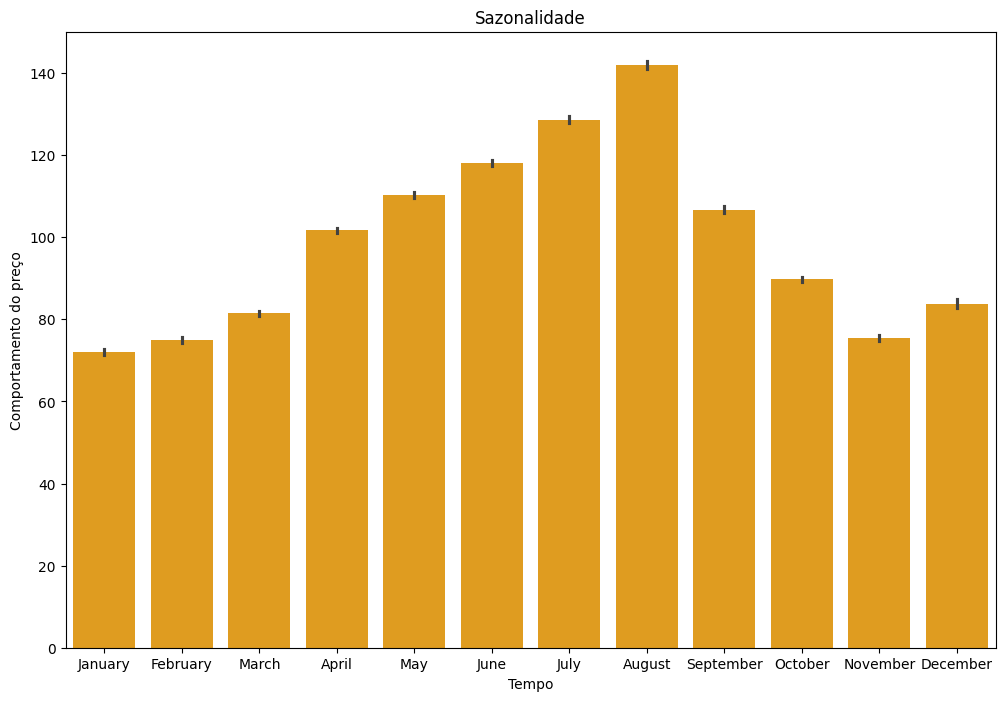

In [176]:
# Sazonalidade. Grafico de linhas.
plt.figure(figsize=(12,8), dpi=(100))
sns.barplot(data = reservas_limpo , x='arrival_date_month', y='adr', order=month_of_year, color='orange')
plt.title('Sazonalidade', fontsize=12)
plt.xlabel('Tempo', fontsize=10)
plt.ylabel('Comportamento do preço', fontsize=10)
plt.show()


Consumo, aumenta nas ferias ou seja verao (hemisferio norte).
Dados de tempo vs comportamento Sazonalidade

In [160]:
#Faturamento por reservas
df_consumo['df_revenue'] = df_consumo['adr']* df_consumo['total_nights']
df_consumo.head(50)

/tmp/ipykernel_855/1015310947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_consumo['df_revenue'] = df_consumo['adr']* df_consumo['total_nights']


,hotel,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,reserved_room_type,assigned_room_type,customer_type,adr,reservation_status,total_of_special_requests,total_hospedes,total_nights,df_revenue
2,Resort Hotel,2015,July,0,1,1,0.0,GBR,Direct,A,C,Transient,75.00,Check-Out,0,1.0,1,75.00
3,Resort Hotel,2015,July,0,1,1,0.0,GBR,Corporate,A,A,Transient,75.00,Check-Out,0,1.0,1,75.00
4,Resort Hotel,2015,July,0,2,2,0.0,GBR,Online TA,A,A,Transient,98.00,Check-Out,1,2.0,2,196.00
5,Resort Hotel,2015,July,0,2,2,0.0,GBR,Online TA,A,A,Transient,98.00,Check-Out,1,2.0,2,196.00
6,Resort Hotel,2015,July,0,2,2,0.0,PRT,Direct,C,C,Transient,107.00,Check-Out,0,2.0,2,214.00
7,Resort Hotel,2015,July,0,2,2,0.0,PRT,Direct,C,C,Transient,103.00,Check-Out,1,2.0,2,206.00
11,Resort Hotel,2015,July,0,4,2,0.0,PRT,Online TA,D,D,Transient,145.00,Check-Out,0,2.0,4,580.00
12,Resort Hotel,2015,July,0,4,2,0.0,USA,Online TA,D,E,Transient,97.00,Check-Out,3,2.0,4,388.00
13,Resort Hotel,2015,July,0,4,2,1.0,ESP,Online TA,G,G,Transient,154.77,Check-Out,1,3.0,4,619.08
14,Resort Hotel,2015,July,0,4,2,0.0,PRT,Online TA,E,E,Transient,94.71,Check-Out,0,2.0,4,378.84


Promedio de Tarifário dependiendo del Mes

In [161]:
reservas_limpo[['arrival_date_month', 'adr']].groupby(by=['arrival_date_month']).mean()

,adr
arrival_date_month,
April,101.651327
August,141.947548
December,83.846390
February,74.979667
January,71.994844
July,128.648610
June,117.990814
March,81.449459
May,110.343011


Cuanto gasta una persona promedio dependiendo de los dias que se esté hospedando? Aqui podemos concluir dos cosas: Si bien, Agosto es uno de los meses con el mayor demanda por ende un valor mas alto que el de los demas meses en el Average Daily Rate podemos decir que en relacion a la cantidad de noches reservas Julio es de los meses con mayor hospedaje, creeriamos, vacaciones estudiantiles, etc. Apesar de que enero, sea el mes con el precio mas accesible, el nivel de demanda ocupacional no remite a una direncia abismal entre los meses de mayor resgate monetario. Se podrian crear, mayores atractivos para los meses con menor ADR para generar, mayores ingresos.

Consolidar la hisotoria entre July vs January

In [ ]:
#Elasticidad de demanda
reservas_limpo[['adr', 'total_nights', 'arrival_date_month']].groupby(by=['arrival_date_month']).mean()


Cuanto pagó por noche y Cuantas noches se quedó? Antes, como el orden de las categorias del calendario arrival_date_month no estarian ordenadas para entender mejor los graficos y resultados, debemos crear un orden categorico para recrear un nuevo calendario y de esa forma, hacerle entender a python que es ese el orden que debe respetar y no el anterior

In [ ]:
#Data Wrangling Gasto promedio mensual
reservas_limpo['arrival_date_month']=pd.Categorical(reservas_limpo['arrival_date_month'], categories =month_of_year , ordered=True)
reservas_limpo.info()

In [ ]:
#Arquitectura del analisis. Segmentacion, Fragmentacion y Estacionalidad
df_consumo[['arrival_date_month', 'hotel','df_revenue']].groupby(by=['hotel','arrival_date_month']).sum()

In [ ]:
#1  Gráfico que representa el valor total segun Hotel vs Tiempo (meses) ¿Que paso?
variable=df_consumo[['arrival_date_month', 'hotel','df_revenue']].groupby(by=['hotel','arrival_date_month']).sum() .reset_index()
#2
plt.figure(figsize=(12,8), dpi=(100))
sns.lineplot(data=variable, x='arrival_date_month', y='df_revenue', hue='hotel', marker='o',linewidth=3, color='orange')
plt.title('LinePlot da Soma Total', fontsize=12)
plt.show()